# FxNet Baseline Training

This notebook implements the baseline audio effect classification pipeline using the convolutional **FxNet** architecture on the GUITAR-FX dataset.

## 1. Setup & Imports

Load core dependencies, project utilities, and hardware acceleration drivers (DirectML GPU or CUDA).

In [3]:
import os
import sys
import time
import json
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from IPython.display import display, clear_output

# Ensure project root is in sys.path when running from notebooks/
sys.path.append('..')
from src.data.dataset import FxDataset
from src.data.datasplit import DataSplit
from src.models.fxnet import FxNet
from src.utils.metrics import compute_metrics, plot_confusion_matrix
from src.utils.device import get_device

# Enable inline plotting
%matplotlib inline


## 2. Configuration

Select the dataset scenario to train (`mono_disc`, `mono_cont`, `poly_disc`, or `poly_cont`) and define training hyperparameters.

In [26]:
# --- SCENARIO SELECTOR ---
# 'mono_disc' | 'mono_cont' | 'poly_disc' | 'poly_cont'
DATASET_TYPE = 'poly_cont'

# Global hyperparameters
SEED = 42
EPOCHS = 30
BATCH_SIZE = 100
LEARNING_RATE = 0.001
# Set to None for automatic hardware detection (AMD GPU via DirectML or NVIDIA via CUDA)
# Or force explicitly: 'dml' (AMD on Windows), 'cuda', or 'cpu'
DEVICE_NAME = None
NUM_WORKERS = 0
CACHE_IN_RAM = True

# Scenario-specific dataset root and parameters
if DATASET_TYPE == 'mono_disc':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Mono_Discrete'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'mono_cont':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Mono_Continuous'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'poly_disc':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Poly_Discrete'
    EXCL_FOLDERS = ['MT2']
elif DATASET_TYPE == 'poly_cont':
    DATASET_ROOT = '../../datasets/GUITAR-FX-DIST/Poly_Continuous'
    EXCL_FOLDERS = ['MT2']
else:
    raise ValueError(f"Unknown DATASET_TYPE: {DATASET_TYPE}")

SPECTRA_FOLDER = 'mel_22050_1024_512'

# Output directories
CHECKPOINTS_DIR = "../checkpoints"
RESULTS_DIR = "../results/baseline"
SCENARIO_RESULTS_DIR = os.path.join(RESULTS_DIR, DATASET_TYPE)

os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCENARIO_RESULTS_DIR, exist_ok=True)

print(f"[{DATASET_TYPE.upper()}] Configuration loaded.")
print(f"-> ROOT: {DATASET_ROOT}")


[POLY_CONT] Configuration loaded.
-> ROOT: ../../datasets/GUITAR-FX-DIST/Poly_Continuous


## 3. Data Loading & Splitting

Initialize the dataset, verify sample counts and effect classes, and partition data into train, validation, and test subsets.

In [27]:
device = get_device(DEVICE_NAME)
print(f"Selected compute device: {device}")

print("Loading dataset...")
dataset = FxDataset(
    root=DATASET_ROOT,
    excl_folders=EXCL_FOLDERS,
    spectra_folder=SPECTRA_FOLDER,
    cache_in_ram=CACHE_IN_RAM,
)
dataset.init_dataset()

print(f"Total dataset samples: {len(dataset):,}")
print(f"Number of effect classes: {dataset.num_fx}")

split = DataSplit(
    dataset,
    test_train_split=0.8,
    val_train_split=0.1,
    shuffle=True,
    seed=SEED,
)

train_loader, val_loader, test_loader = split.get_split(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
)

print(f"Data Split -> Train: {len(split.train_sampler):,} | Val: {len(split.val_indices):,} | Test: {len(split.test_indices):,}")


Selected compute device: privateuseone:0
Loading dataset...
Total dataset samples: 130,000
Number of effect classes: 13
Data Split -> Train: 93,600 | Val: 10,400 | Test: 26,000


## 4. Model Instantiation

Instantiate the convolutional FxNet architecture, Cross-Entropy loss criterion, and optimizer (with DirectML GPU support for AMD on Windows).

In [28]:
class DirectMLAdam(optim.Optimizer):
    """Adam optimizer using basic ops natively supported on DirectML GPU."""
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            lr = group["lr"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                state["step"] += 1
                bias_correction1 = 1.0 - (beta1 ** state["step"])
                bias_correction2 = 1.0 - (beta2 ** state["step"])

                exp_avg.mul_(beta1).add_(grad, alpha=1.0 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)
                denom = (exp_avg_sq.sqrt() / (bias_correction2 ** 0.5)).add_(eps)
                step_size = lr / bias_correction1
                p.addcdiv_(exp_avg, denom, value=-step_size)
        return loss

model = FxNet(n_classes=dataset.num_fx).to(device)

if "privateuseone" in str(device) or "dml" in str(device):
    optimizer = DirectMLAdam(model.parameters(), lr=LEARNING_RATE)
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
criterion = nn.CrossEntropyLoss()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"FxNet initialized with {trainable_params:,} trainable parameters.")


FxNet initialized with 762,217 trainable parameters.


## 5. Training

Execute epoch iterations over training and validation sets, track losses and accuracies, and checkpoint the best-performing model weights.

In [33]:
best_val_acc = 0.0
epoch_times = []
train_losses, val_losses = [], []
train_accs, val_accs = [], []

total_start_time = time.time()
best_checkpoint_path = os.path.join(CHECKPOINTS_DIR, f"best_model_{DATASET_TYPE}.pt")

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, data in enumerate(train_loader):
        if data is None: continue
        inputs, labels, _, _, _ = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct_train += preds.eq(labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / max(total_train, 1)
    train_acc = (correct_train / max(total_train, 1)) * 100
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    val_loss_total = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_idx, data in enumerate(val_loader):
            if data is None: continue
            inputs, labels, _, _, _ = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)
            correct_val += preds.eq(labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss_total / max(total_val, 1)
    val_acc = (correct_val / max(total_val, 1)) * 100
    
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    epoch_duration = time.time() - epoch_start
    epoch_times.append(epoch_duration)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] ({epoch_duration:.2f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  -> Best model saved (Val Acc: {val_acc:.2f}%)")

total_duration = time.time() - total_start_time
avg_epoch_time = sum(epoch_times) / max(len(epoch_times), 1)

print("=" * 60)
print(f"TRAINING COMPLETED in {total_duration/60:.2f} minutes.")
print(f"Average time per epoch: {avg_epoch_time:.2f} seconds.")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("=" * 60)


KeyboardInterrupt: 

## 6. Training Metrics Plot

Visualize and save training and validation Loss and Accuracy curves across epochs into a single image file.

Training curves saved to: ../results\poly_cont\training_curves_poly_cont.png


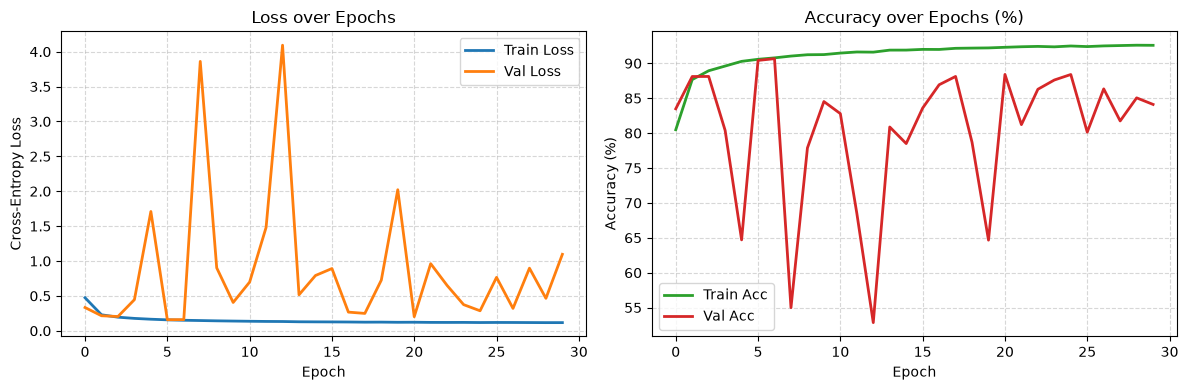

In [30]:
# Plot and save Loss and Accuracy curves in a single file
curves_path = os.path.join(SCENARIO_RESULTS_DIR, f"training_curves_{DATASET_TYPE}.png")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2)
plt.title('Loss over Epochs', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Cross-Entropy Loss', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='#2ca02c', linewidth=2)
plt.plot(val_accs, label='Val Acc', color='#d62728', linewidth=2)
plt.title('Accuracy over Epochs (%)', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Accuracy (%)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(curves_path, dpi=300, bbox_inches='tight')
print(f"Training curves saved to: {curves_path}")
plt.show()


## 7. Evaluation (Test Set)

Load the best checkpoint weights, evaluate classification performance on the held-out test set, and generate the normalized confusion matrix.

Loading best model checkpoint from ../checkpoints\best_model_poly_cont.pt


C:\Users\caduo\AppData\Local\Temp\ipykernel_20880\3224311699.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint_path, map_l

FINAL TEST RESULTS:
Test Accuracy:   89.83%
Test F1-Score:   88.19%
Macro Precision: 90.05%
Macro Recall:    90.11%


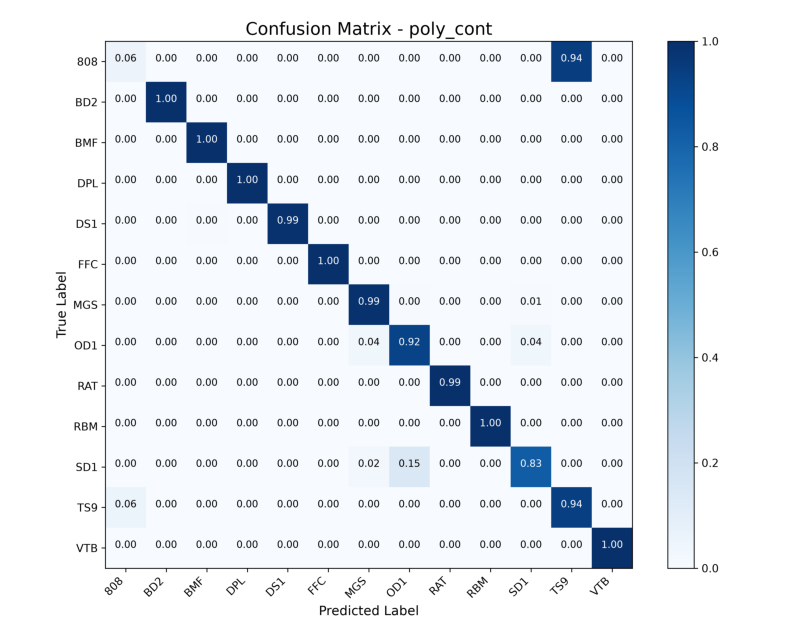

In [31]:
# Load best checkpoint weights
if os.path.exists(best_checkpoint_path):
    print(f"Loading best model checkpoint from {best_checkpoint_path}")
    model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))

model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for batch_idx, data in enumerate(test_loader):
        if data is None: continue
        inputs, labels, _, _, _ = data
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

class_names = [dataset.label_to_fx[i] for i in range(dataset.num_fx)]
test_metrics = compute_metrics(test_targets, test_preds, class_names=class_names)

print("=" * 60)
print("FINAL TEST RESULTS:")
print(f"Test Accuracy:   {test_metrics['accuracy']*100:.2f}%")
print(f"Test F1-Score:   {test_metrics['macro_f1']*100:.2f}%")
print(f"Macro Precision: {test_metrics['macro_precision']*100:.2f}%")
print(f"Macro Recall:    {test_metrics['macro_recall']*100:.2f}%")
print("=" * 60)

# Confusion Matrix
cm_path = os.path.join(SCENARIO_RESULTS_DIR, f"confusion_matrix_{DATASET_TYPE}.png")
plot_confusion_matrix(
    test_metrics["confusion_matrix"],
    classes=class_names,
    save_path=cm_path,
    normalize=True,
    title=f"Confusion Matrix - {DATASET_TYPE}",
)

# Display generated confusion matrix plot
import matplotlib.image as mpimg
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()


## 8. Results Reporting & Summary Table

Automatically update a persistent benchmark summary table and markdown report comparing results against the reference paper baseline (Comunità et al.).

In [32]:
# Reference paper baselines (Comunità et al., 13 classes)
PAPER_BENCHMARKS = {
    "mono_disc": 86.30,
    "mono_cont": 90.90,
    "poly_disc": 88.40,
    "poly_cont": 91.40,
}

SCENARIO_DISPLAY_NAMES = {
    "mono_disc": "Mono Discrete",
    "mono_cont": "Mono Continuous",
    "poly_disc": "Poly Discrete",
    "poly_cont": "Poly Continuous",
}

# Current execution summary record
current_record = {
    "scenario_key": DATASET_TYPE,
    "dataset": SCENARIO_DISPLAY_NAMES.get(DATASET_TYPE, DATASET_TYPE),
    "test_acc": round(test_metrics["accuracy"] * 100, 2),
    "paper_acc": PAPER_BENCHMARKS.get(DATASET_TYPE, 0.0),
    "diff": round(test_metrics["accuracy"] * 100 - PAPER_BENCHMARKS.get(DATASET_TYPE, 0.0), 2),
    "best_val_acc": round(best_val_acc, 2),
    "macro_f1": round(test_metrics["macro_f1"] * 100, 2),
    "macro_prec": round(test_metrics["macro_precision"] * 100, 2),
    "macro_rec": round(test_metrics["macro_recall"] * 100, 2),
    "train_loss": round(train_losses[-1], 4),
    "val_loss": round(val_losses[-1], 4),
    "epochs": EPOCHS,
    "duration_min": round(total_duration / 60, 2),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
}

# Load or initialize persistent summary JSON
summary_json_path = os.path.join(RESULTS_DIR, "baseline_results_summary.json")
records = {}
if os.path.exists(summary_json_path):
    try:
        with open(summary_json_path, "r", encoding="utf-8") as f:
            records = json.load(f)
    except Exception:
        records = {}

# Update with current scenario results
records[DATASET_TYPE] = current_record

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)

# Convert to DataFrame ordered by standard scenario order
ordered_keys = ["mono_disc", "mono_cont", "poly_disc", "poly_cont"]
table_data = [records[k] for k in ordered_keys if k in records]

# Column definitions for display and markdown
display_headers = {
    "dataset": "Dataset Scenario",
    "test_acc": "Test Acc (%)",
    "paper_acc": "Paper Baseline (%)",
    "diff": "Diff (%)",
    "best_val_acc": "Best Val Acc (%)",
    "macro_f1": "Macro F1 (%)",
    "train_loss": "Final Train Loss",
    "val_loss": "Final Val Loss",
    "epochs": "Epochs",
    "duration_min": "Time (min)",
    "timestamp": "Run Date",
}

df_summary = pd.DataFrame(table_data)
df_display = df_summary[[c for c in display_headers.keys() if c in df_summary.columns]].rename(columns=display_headers)

print("=" * 80)
print("BASELINE BENCHMARK SUMMARY TABLE:")
print("=" * 80)
display(df_display)

# Helper function to generate clean Markdown tables without external dependencies
def build_markdown_table(rows, headers):
    header_row = "| " + " | ".join(headers.values()) + " |"
    separator_row = "| " + " | ".join([":---:" for _ in headers]) + " |"
    data_rows = []
    for r in rows:
        formatted_row = []
        for k in headers.keys():
            val = r.get(k, "-")
            if k == "diff" and isinstance(val, (int, float)):
                val = f"{val:+.2f}%"
            elif k in ["test_acc", "paper_acc", "best_val_acc", "macro_f1"] and isinstance(val, (int, float)):
                val = f"{val:.2f}%"
            formatted_row.append(str(val))
        data_rows.append("| " + " | ".join(formatted_row) + " |")
    return "\n".join([header_row, separator_row] + data_rows)

# Write / Update Markdown Report
report_md_path = os.path.join(RESULTS_DIR, "baseline_results_report.md")
with open(report_md_path, "w", encoding="utf-8") as f:
    f.write("# FxNet Baseline Training - Benchmark Results Report\n\n")
    f.write("This report is automatically fed and updated at the end of each training scenario.\n\n")
    f.write("## Overall Performance Comparison\n\n")
    f.write(build_markdown_table(table_data, display_headers) + "\n\n")
    f.write("## Detailed Scenario Artifacts\n\n")
    for k in ordered_keys:
        if k in records:
            r = records[k]
            f.write(f"### {r['dataset']}\n")
            f.write(f"- **Test Accuracy**: {r['test_acc']}%\n")
            f.write(f"- **Paper Benchmark (Comunità et al.)**: {r['paper_acc']}%\n")
            f.write(f"- **Macro F1-Score**: {r['macro_f1']}%\n")
            f.write(f"- **Macro Precision / Recall**: {r['macro_prec']}% / {r['macro_rec']}%\n")
            f.write(f"- **Best Validation Accuracy**: {r['best_val_acc']}%\n")
            f.write(f"- **Final Losses (Train / Val)**: {r['train_loss']} / {r['val_loss']}\n")
            f.write(f"- **Total Training Time**: {r['duration_min']} minutes ({r['epochs']} epochs)\n")
            f.write(f"- **Checkpoint**: `checkpoints/best_model_{k}.pt`\n")
            f.write(f"- **Confusion Matrix**: `results/baseline/{k}/confusion_matrix_{k}.png`\n")
            f.write(f"- **Training Curves (Loss & Acc)**: `results/baseline/{k}/training_curves_{k}.png`\n")
            f.write(f"- **Classification Report**: `results/baseline/{k}/classification_report_{k}.txt`\n\n")

print(f"\nSummary report updated at: {os.path.abspath(report_md_path)}")

# Also save detailed per-class classification report text file for the current run
class_report_str = classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0)
txt_report_path = os.path.join(SCENARIO_RESULTS_DIR, f"classification_report_{DATASET_TYPE}.txt")
with open(txt_report_path, "w", encoding="utf-8") as f:
    f.write(f"Classification Report - {SCENARIO_DISPLAY_NAMES.get(DATASET_TYPE, DATASET_TYPE)}\n")
    f.write(f"Execution Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 60 + "\n\n")
    f.write(class_report_str + "\n")

print(f"Per-class classification report saved to: {os.path.abspath(txt_report_path)}")


BASELINE BENCHMARK SUMMARY TABLE:


,Dataset Scenario,Test Acc (%),Paper Baseline (%),Diff (%),Best Val Acc (%),Macro F1 (%),Final Train Loss,Final Val Loss,Epochs,Time (min),Run Date
0,Mono Discrete,86.61,86.3,0.31,87.22,83.31,0.1740,0.2148,30,9.45,2026-09-24 20:02
1,Mono Continuous,90.02,90.9,-0.88,90.64,90.03,0.1429,0.2768,30,10.90,2026-09-24 20:23
2,Poly Discrete,87.73,88.4,-0.67,88.35,88.90,0.1581,2.0247,30,6.49,2026-09-24 20:30
3,Poly Continuous,89.83,91.4,-1.57,90.66,88.19,0.1171,1.0960,30,10.16,2026-09-24 20:42



Summary report updated at: c:\Users\caduo\dev\tcc\tcc\results\baseline_results_report.md
Per-class classification report saved to: c:\Users\caduo\dev\tcc\tcc\results\poly_cont\classification_report_poly_cont.txt
